In [1]:
import pandas as pd
import os
pd.set_option("display.max_columns", None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calmap
import gc
import statistics as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_parquet("../../data/raw/all_flights_2018-2022_raw.parquet")
df.shape

(29193782, 62)

In this dataset, we have over 29 million flights from 2018-2022 in the United States.

In [3]:
df.head()

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings,year
0,2018-01-23,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,1256.0,0.0,38.0,62.0,59.0,145.0,2018,1,1,23,2,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8928A,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,14.0,1211.0,1249.0,7.0,1304,-8.0,0.0,-1.0,1300-1359,1,0.0,2018
1,2018-01-24,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,1258.0,0.0,36.0,62.0,61.0,145.0,2018,1,1,24,3,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N800AY,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,13.0,1210.0,1246.0,12.0,1304,-6.0,0.0,-1.0,1300-1359,1,0.0,2018
2,2018-01-25,Endeavor Air Inc.,ABY,ATL,False,False,1202,1153.0,0.0,-9.0,1302.0,0.0,40.0,62.0,69.0,145.0,2018,1,1,25,4,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8836A,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,18.0,1211.0,1251.0,11.0,1304,-2.0,0.0,-1.0,1300-1359,1,0.0,2018
3,2018-01-26,Endeavor Air Inc.,ABY,ATL,False,False,1202,1150.0,0.0,-12.0,1253.0,0.0,35.0,62.0,63.0,145.0,2018,1,1,26,5,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N800AY,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,17.0,1207.0,1242.0,11.0,1304,-11.0,0.0,-1.0,1300-1359,1,0.0,2018
4,2018-01-27,Endeavor Air Inc.,ABY,ATL,False,False,1400,1355.0,0.0,-5.0,1459.0,0.0,36.0,60.0,64.0,145.0,2018,1,1,27,6,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8839E,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1400-1459,17.0,1412.0,1448.0,11.0,1500,-1.0,0.0,-1.0,1500-1559,1,0.0,2018


In [4]:
df.columns

Index(['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled', 'Diverted',
       'CRSDepTime', 'DepTime', 'DepDelayMinutes', 'DepDelay', 'ArrTime',
       'ArrDelayMinutes', 'AirTime', 'CRSElapsedTime', 'ActualElapsedTime',
       'Distance', 'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek',
       'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners',
       'DOT_ID_Marketing_Airline', 'IATA_Code_Marketing_Airline',
       'Flight_Number_Marketing_Airline', 'Operating_Airline',
       'DOT_ID_Operating_Airline', 'IATA_Code_Operating_Airline',
       'Tail_Number', 'Flight_Number_Operating_Airline', 'OriginAirportID',
       'OriginAirportSeqID', 'OriginCityMarketID', 'OriginCityName',
       'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac',
       'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestCityName',
       'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'DepDel15',
       'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOu

In [5]:
df.dtypes.value_counts()

int64             23
float64           19
object            17
bool               2
datetime64[us]     1
Name: count, dtype: int64

In [6]:
df.describe(include=[np.number]).T.head(10)

,count,mean,std,min,25%,50%,75%,max
CRSDepTime,29193782.0,1326.261738,482.346300,1.0,918.0,1320.0,1730.0,2359.0
DepTime,28432130.0,1329.295567,494.975040,1.0,920.0,1323.0,1736.0,2400.0
DepDelayMinutes,28430698.0,12.783107,46.173367,0.0,0.0,0.0,5.0,7223.0
DepDelay,28430698.0,9.306866,47.280106,-1280.0,-6.0,-3.0,5.0,7223.0
ArrTime,28407605.0,1468.046257,525.617712,1.0,1055.0,1505.0,1910.0,2400.0
ArrDelayMinutes,28347599.0,12.809917,45.799592,0.0,0.0,0.0,6.0,7232.0
AirTime,28341221.0,109.087503,69.066686,-1244.0,59.0,91.0,138.0,1557.0
CRSElapsedTime,29193760.0,138.760512,70.773163,-292.0,88.0,121.0,169.0,1645.0
ActualElapsedTime,28348145.0,133.294120,70.778028,-1228.0,82.0,116.0,164.0,1604.0
Distance,29193782.0,779.734565,581.273883,16.0,354.0,626.0,1014.0,5812.0


## Missing values (high-level, model-oriented)

In [7]:
# Missingness percentage (top 15)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct.head(15)

AirTime                 2.920351
ArrDelay                2.898504
ArrivalDelayGroups      2.898504
ArrDel15                2.898504
ArrDelayMinutes         2.898504
ActualElapsedTime       2.896634
TaxiIn                  2.716822
WheelsOn                2.716787
ArrTime                 2.692960
TaxiOut                 2.673723
WheelsOff               2.673689
DepDelayMinutes         2.613858
DepartureDelayGroups    2.613858
DepDel15                2.613858
DepDelay                2.613858
dtype: float64

In [8]:
# Columns with >20% missing
missing_pct[missing_pct > 20]

Series([], dtype: float64)

Missing values are minimal across the dataset (≈2–3% at most). Columns with missing data are primarily flight-operation fields (e.g., AirTime, ArrDelay, TaxiIn), which are expected to be missing for cancelled flights. No columns exceed 20% missingness, indicating strong overall data quality. Missingness is treated as informative rather than erroneous.

### Target Variable

The column we want to predict is the status of the flight. Which we have to manually create using these columns: "Cancelled", "ArrDelayMinutes", "Diverted", or if none, then on time.

- If "Cancelled" = True --> Cancelled
- If "DepDelayMinutes" >= 15 --> Delayed
- If none, --> On time

In [9]:
# Let's make sure there are none that are cancelled and delayed
# 1.2% of the cancelled flights are cancelled yet have a departure delay minutes value -- which is contradicting
df[(df.Cancelled == True) & (df.DepDelayMinutes > 0)].shape[0]/(df[df.Cancelled==True].shape[0])


0.012506641861805532

In [10]:
conditions = [
    df["Cancelled"] == True,
    df["DepDelayMinutes"] >= 15
]

choices = [
    "Cancelled",
    "Delayed"
]

df["target"] = np.select(
    conditions,
    choices,
    default="On time"
)


In [11]:
df["target"].value_counts(), df["target"].value_counts(normalize=True)

(target
 On time      23512421
 Delayed       4904094
 Cancelled      777267
 Name: count, dtype: int64,
 target
 On time      0.805391
 Delayed      0.167984
 Cancelled    0.026624
 Name: proportion, dtype: float64)

Flights are labeled as **On time**, **Delayed** (≥15 minutes), or **Cancelled**.  
Most flights are on time (~80%), with fewer delayed (~17%) and cancelled (~3%), indicating class imbalance.

In [12]:
# target variables---> Cancelled, Delayed(>=15min), On time
conditions = [
df['Cancelled'] == True,
df['DepDelayMinutes'] >= 15
]
choices = ['Cancelled', 'Delayed']
df['target'] = np.select(conditions, choices, default='On time')


class_counts = df['target'].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()

# target distribution & percentages
print("\nTarget distribution:")
print(class_counts)
print("\nTarget %:")
print((class_counts / class_counts.sum()) * 100)


Target distribution:
target
On time      23512421
Delayed       4904094
Cancelled      777267
Name: count, dtype: int64

Target %:
target
On time      80.53914
Delayed      16.79842
Cancelled     2.66244
Name: count, dtype: float64


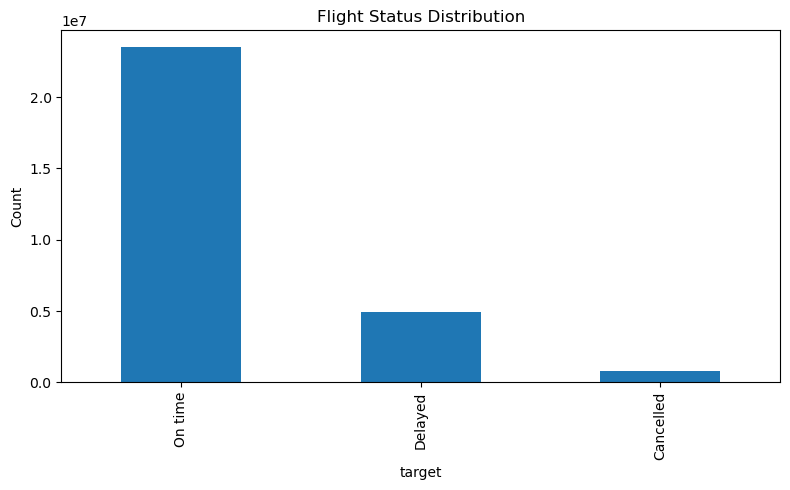

In [13]:
# target dist bar
plt.figure(figsize=(8,5))
class_counts.plot(kind='bar')
plt.title('Flight Status Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

* shows a major class imbalance: most flights are on time (80%) with some delayed (17%) and even fewer cancelled flights (3%)

**Something we have to keep an eye on!!**
potential fixes:
1. class weights in loss function 
2. stratified sampling to maintain class proportions during training 

## Leakage check

In [14]:
# Columns that should NOT be used as features
leakage_cols = [
    "ArrDelay", "ArrDelayMinutes", "ActualElapsedTime",
    "AirTime", "WheelsOff", "WheelsOn", "TaxiIn"
]

[c for c in leakage_cols if c in df.columns]

['ArrDelay',
 'ArrDelayMinutes',
 'ActualElapsedTime',
 'AirTime',
 'WheelsOff',
 'WheelsOn',
 'TaxiIn']

Post-event features that reveal flight outcomes (arrival delay, airtime, taxi-in, etc.) are present in the dataset and must be excluded to prevent data leakage.

## Temporal Features

In [15]:
# Ensure FlightDate is datetime
df["FlightDate"] = pd.to_datetime(df["FlightDate"])

# Basic temporal features
df["month"] = df["FlightDate"].dt.month
df["day_of_week"] = df["FlightDate"].dt.dayofweek  # 0=Mon
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

In [16]:
df[["month", "day_of_week", "is_weekend"]].describe()

,month,day_of_week,is_weekend
count,2.919378e+07,2.919378e+07,2.919378e+07
mean,6.327840e+00,2.974879e+00,2.732330e-01
std,3.452305e+00,2.002314e+00,4.456195e-01
min,1.000000e+00,0.000000e+00,0.000000e+00
25%,3.000000e+00,1.000000e+00,0.000000e+00
50%,6.000000e+00,3.000000e+00,0.000000e+00
75%,9.000000e+00,5.000000e+00,1.000000e+00
max,1.200000e+01,6.000000e+00,1.000000e+00


In [17]:
# Target rate by month
df.groupby("month")["target"].value_counts(normalize=True).unstack()

target,Cancelled,Delayed,On time
month,,,
1,0.029807,0.154012,0.816181
2,0.031232,0.171879,0.796889
3,0.055753,0.144092,0.800155
4,0.068321,0.151852,0.779827
5,0.019112,0.174387,0.806501
6,0.019656,0.218708,0.761636
7,0.016830,0.205922,0.777248
8,0.021350,0.187978,0.790672
9,0.013948,0.129933,0.856119


In [18]:
# Target rate by weekday
df.groupby("day_of_week")["target"].value_counts(normalize=True).unstack()

target,Cancelled,Delayed,On time
day_of_week,,,
0,0.027473,0.172596,0.799931
1,0.024942,0.152923,0.822134
2,0.026449,0.152318,0.821233
3,0.028582,0.176712,0.794707
4,0.026138,0.183442,0.790421
5,0.025290,0.160786,0.813923
6,0.027199,0.174380,0.798421


Temporal features (month, day of week, weekend) show clear seasonal and weekly patterns in delays and cancellations. These features are simple, non-leaky, and useful for improving model performance.

## Categorical Features (Airline & Airports)

In [19]:
# Target distribution by airline
airline_target = (
    df.groupby("Airline")["target"]
      .value_counts(normalize=True)
      .unstack()
      .sort_values("Delayed", ascending=False)
)

airline_target.head(10)

target,Cancelled,Delayed,On time
Airline,,,
Peninsula Airways Inc.,0.154869,0.279914,0.565217
JetBlue Airways,0.026305,0.249012,0.724683
Frontier Airlines Inc.,0.024069,0.235478,0.740453
"Commutair Aka Champlain Enterprises, Inc.",0.042319,0.223705,0.733976
Trans States Airlines,0.040931,0.218256,0.740813
Allegiant Air,0.045789,0.215018,0.739193
Southwest Airlines Co.,0.031311,0.207303,0.761386
Spirit Air Lines,0.021693,0.179570,0.798738
"GoJet Airlines, LLC d/b/a United Express",0.033419,0.175206,0.791375


In [20]:
# Top origin airports by volume
top_origins = df["Origin"].value_counts().head(15).index

origin_target = (
    df[df["Origin"].isin(top_origins)]
    .groupby("Origin")["target"]
    .value_counts(normalize=True)
    .unstack()
    .sort_values("Delayed", ascending=False)
)

origin_target

target,Cancelled,Delayed,On time
Origin,,,
EWR,0.041750,0.231159,0.727091
MCO,0.023786,0.209182,0.767032
DEN,0.025351,0.207530,0.767118
LAS,0.024673,0.198618,0.776709
DFW,0.033233,0.192059,0.774708
ORD,0.032244,0.181773,0.785983
PHX,0.020492,0.178987,0.800521
SFO,0.023121,0.172479,0.804400
LAX,0.018394,0.164384,0.817222


In [21]:
# Top destination airports by volume
top_dests = df["Dest"].value_counts().head(15).index

dest_target = (
    df[df["Dest"].isin(top_dests)]
    .groupby("Dest")["target"]
    .value_counts(normalize=True)
    .unstack()
    .sort_values("Delayed", ascending=False)
)

dest_target

target,Cancelled,Delayed,On time
Dest,,,
EWR,0.042472,0.238086,0.719443
MCO,0.024674,0.199129,0.776197
SFO,0.023160,0.195325,0.781514
LAS,0.024769,0.184462,0.790768
PHX,0.021632,0.165776,0.812592
DFW,0.034128,0.163452,0.802420
ORD,0.033489,0.163332,0.803178
DEN,0.026445,0.161552,0.812003
LAX,0.018904,0.161113,0.819982


Delay and cancellation rates vary by airline.
Busy airports (origins and destinations) tend to have higher delay rates.
Airline and airport information are useful categorical predictors for modeling.

## Numerical feature

In [22]:
# Numerical feature overview
num_cols = [
    "Distance", "CRSElapsedTime", "DepDelayMinutes"
]

df[num_cols].describe()

,Distance,CRSElapsedTime,DepDelayMinutes
count,2.919378e+07,2.919376e+07,2.843070e+07
mean,7.797346e+02,1.387605e+02,1.278311e+01
std,5.812739e+02,7.077316e+01,4.617337e+01
min,1.600000e+01,-2.920000e+02,0.000000e+00
25%,3.540000e+02,8.800000e+01,0.000000e+00
50%,6.260000e+02,1.210000e+02,0.000000e+00
75%,1.014000e+03,1.690000e+02,5.000000e+00
max,5.812000e+03,1.645000e+03,7.223000e+03


Numerical features vary widely, with distance and scheduled time reflecting route characteristics and departure delays showing strong right skew due to many on-time flights.

In [23]:
df.isnull().sum().sort_values(ascending=False).head(20)

AirTime                 852561
ArrDel15                846183
ArrDelay                846183
ArrivalDelayGroups      846183
ArrDelayMinutes         846183
ActualElapsedTime       845637
TaxiIn                  793143
WheelsOn                793133
ArrTime                 786177
TaxiOut                 780561
WheelsOff               780551
DepartureDelayGroups    763084
DepDel15                763084
DepDelay                763084
DepDelayMinutes         763084
DepTime                 761652
Tail_Number             267613
DivAirportLandings          90
CRSElapsedTime              22
DestStateFips                0
dtype: int64

In [24]:
852561 / df.shape[0]

0.029203513268681668

Below is the data quality of the columns, the number of null values per column.
Although for some columns such as "AirTime", "ArrDelayMinutes", and more -- it makes sense to have null values given if a flight is cancelled, there will be no air time, etc.

### Airport Distance Correlations

Let's look at the distance between airports to see how they are correlated to the status

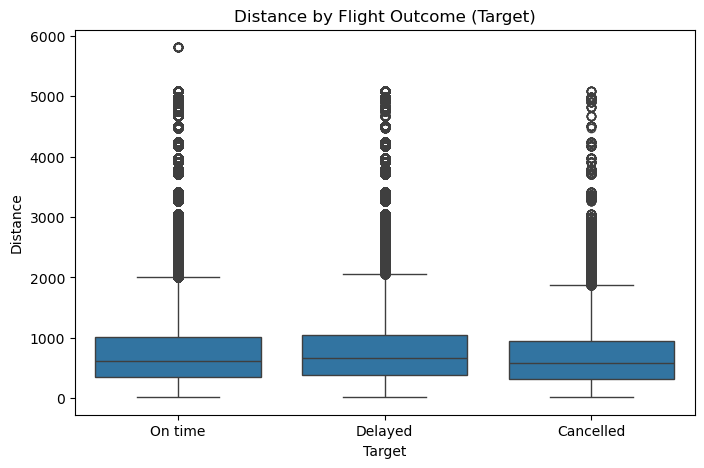

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="target",
    y="Distance"
)

plt.title("Distance by Flight Outcome (Target)")
plt.xlabel("Target")
plt.ylabel("Distance")
plt.show()


There doesn't seem to be any extreme changes in the distance between airports and the status. Differences look minimal.

Now let's look at the airline correlation

In [26]:
df.Airline.value_counts()

Airline
Southwest Airlines Co.                       5474339
Delta Air Lines Inc.                         3294917
SkyWest Airlines Inc.                        3159683
American Airlines Inc.                       3134117
United Air Lines Inc.                        2354538
Republic Airlines                            1283704
JetBlue Airways                              1106079
Envoy Air                                    1072778
Endeavor Air Inc.                             998224
Comair Inc.                                   957220
Alaska Airlines Inc.                          906259
Spirit Air Lines                              836694
Mesa Airlines Inc.                            749216
Frontier Airlines Inc.                        570452
Allegiant Air                                 489400
Horizon Air                                   471153
Capital Cargo International                   392011
Air Wisconsin Airlines Corp                   380202
ExpressJet Airlines Inc.              

In [27]:
df.Airline.value_counts(normalize=True)

Airline
Southwest Airlines Co.                       0.187517
Delta Air Lines Inc.                         0.112864
SkyWest Airlines Inc.                        0.108231
American Airlines Inc.                       0.107356
United Air Lines Inc.                        0.080652
Republic Airlines                            0.043972
JetBlue Airways                              0.037887
Envoy Air                                    0.036747
Endeavor Air Inc.                            0.034193
Comair Inc.                                  0.032788
Alaska Airlines Inc.                         0.031043
Spirit Air Lines                             0.028660
Mesa Airlines Inc.                           0.025664
Frontier Airlines Inc.                       0.019540
Allegiant Air                                0.016764
Horizon Air                                  0.016139
Capital Cargo International                  0.013428
Air Wisconsin Airlines Corp                  0.013023
ExpressJet Airlines 

In [28]:
pd.crosstab(df.Airline, df.target).sort_values("Cancelled", ascending=True)

target,Cancelled,Delayed,On time
Airline,,,
Cape Air,2,132,1527
Peninsula Airways Inc.,431,779,1573
Virgin America,433,3022,14215
Empire Airlines Inc.,1293,3167,18662
Compass Airlines,1986,25589,127410
Hawaiian Airlines Inc.,3146,27689,279947
Trans States Airlines,6614,35268,119708
"GoJet Airlines, LLC d/b/a United Express",9240,48442,218804
"Commutair Aka Champlain Enterprises, Inc.",11005,58174,190869


In [29]:
pd.crosstab(df.Airline, df.target, normalize=True).sort_values("Cancelled", ascending=True)

target,Cancelled,Delayed,On time
Airline,,,
Cape Air,6.850774e-08,0.000005,0.000052
Peninsula Airways Inc.,1.476342e-05,0.000027,0.000054
Virgin America,1.483193e-05,0.000104,0.000487
Empire Airlines Inc.,4.429025e-05,0.000108,0.000639
Compass Airlines,6.802818e-05,0.000877,0.004364
Hawaiian Airlines Inc.,1.077627e-04,0.000948,0.009589
Trans States Airlines,2.265551e-04,0.001208,0.004100
"GoJet Airlines, LLC d/b/a United Express",3.165058e-04,0.001659,0.007495
"Commutair Aka Champlain Enterprises, Inc.",3.769638e-04,0.001993,0.006538


[Text(0, 0, 'Air Wisconsin Airlines Corp'),
 Text(1, 0, 'Alaska Airlines Inc.'),
 Text(2, 0, 'Allegiant Air'),
 Text(3, 0, 'American Airlines Inc.'),
 Text(4, 0, 'Cape Air'),
 Text(5, 0, 'Capital Cargo International'),
 Text(6, 0, 'Comair Inc.'),
 Text(7, 0, 'Commutair Aka Champlain Enterprises, Inc.'),
 Text(8, 0, 'Compass Airlines'),
 Text(9, 0, 'Delta Air Lines Inc.'),
 Text(10, 0, 'Empire Airlines Inc.'),
 Text(11, 0, 'Endeavor Air Inc.'),
 Text(12, 0, 'Envoy Air'),
 Text(13, 0, 'ExpressJet Airlines Inc.'),
 Text(14, 0, 'Frontier Airlines Inc.'),
 Text(15, 0, 'GoJet Airlines, LLC d/b/a United Express'),
 Text(16, 0, 'Hawaiian Airlines Inc.'),
 Text(17, 0, 'Horizon Air'),
 Text(18, 0, 'JetBlue Airways'),
 Text(19, 0, 'Mesa Airlines Inc.'),
 Text(20, 0, 'Peninsula Airways Inc.'),
 Text(21, 0, 'Republic Airlines'),
 Text(22, 0, 'SkyWest Airlines Inc.'),
 Text(23, 0, 'Southwest Airlines Co.'),
 Text(24, 0, 'Spirit Air Lines'),
 Text(25, 0, 'Trans States Airlines'),
 Text(26, 0, 'United

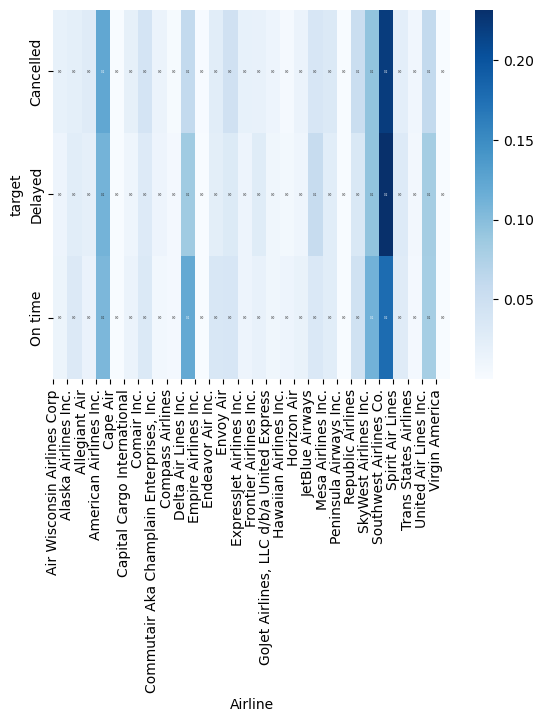

In [30]:
ct_norm = pd.crosstab(
    df["target"],
    df["Airline"],
    normalize="index"
)

ax = sns.heatmap(
    ct_norm,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    annot_kws={"size": 2}
)

ax.set_xticks(range(len(ct_norm.columns)))
ax.set_xticklabels(ct_norm.columns)



We can see some highly concentrated areas are Southwest Airlines where there are a lot of cancelled and delayed flights. As well as American Airlines and Skywest.

Hypothesis:
Another thing to consider are hubs for airlines. I.E. American airline hubs are located in Dallas, Texas where weather tends to be extreme. This can also be a correlation - weather, airline & cancellations.

Let's look at destination flying to and from!

In [31]:
df.head()

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings,year,target,month,day_of_week,is_weekend
0,2018-01-23,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,1256.0,0.0,38.0,62.0,59.0,145.0,2018,1,1,23,2,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8928A,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,14.0,1211.0,1249.0,7.0,1304,-8.0,0.0,-1.0,1300-1359,1,0.0,2018,On time,1,1,0
1,2018-01-24,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,1258.0,0.0,36.0,62.0,61.0,145.0,2018,1,1,24,3,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N800AY,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,13.0,1210.0,1246.0,12.0,1304,-6.0,0.0,-1.0,1300-1359,1,0.0,2018,On time,1,2,0
2,2018-01-25,Endeavor Air Inc.,ABY,ATL,False,False,1202,1153.0,0.0,-9.0,1302.0,0.0,40.0,62.0,69.0,145.0,2018,1,1,25,4,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8836A,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,18.0,1211.0,1251.0,11.0,1304,-2.0,0.0,-1.0,1300-1359,1,0.0,2018,On time,1,3,0
3,2018-01-26,Endeavor Air Inc.,ABY,ATL,False,False,1202,1150.0,0.0,-12.0,1253.0,0.0,35.0,62.0,63.0,145.0,2018,1,1,26,5,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N800AY,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,17.0,1207.0,1242.0,11.0,1304,-11.0,0.0,-1.0,1300-1359,1,0.0,2018,On time,1,4,0
4,2018-01-27,Endeavor Air Inc.,ABY,ATL,False,False,1400,1355.0,0.0,-5.0,1459.0,0.0,36.0,60.0,64.0,145.0,2018,1,1,27,6,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8839E,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1400-1459,17.0,1412.0,1448.0,11.0,1500,-1.0,0.0,-1.0,1500-1559,1,0.0,2018,On time,1,5,1


In [32]:
df.Dest.nunique()

388

In [33]:
df.Origin.nunique()

388

In [34]:
df.OriginState.unique()

array(['GA', 'AL', 'NY', 'TX', 'VT', 'KY', 'VA', 'NC', 'MO', 'MN', 'WI',
       'MI', 'FL', 'LA', 'IN', 'OH', 'IL', 'TN', 'ME', 'SC', 'ND', 'AR',
       'MA', 'OK', 'WV', 'MS', 'PA', 'NE', 'MD', 'IA', 'NH', 'CT', 'NJ',
       'PR', 'UT', 'CA', 'NV', 'CO', 'WA', 'VI', 'RI', 'OR', 'AZ', 'NM',
       'KS', 'MT', 'ID', 'SD', 'HI', 'WY', 'TT', 'AK', 'DE'], dtype=object)

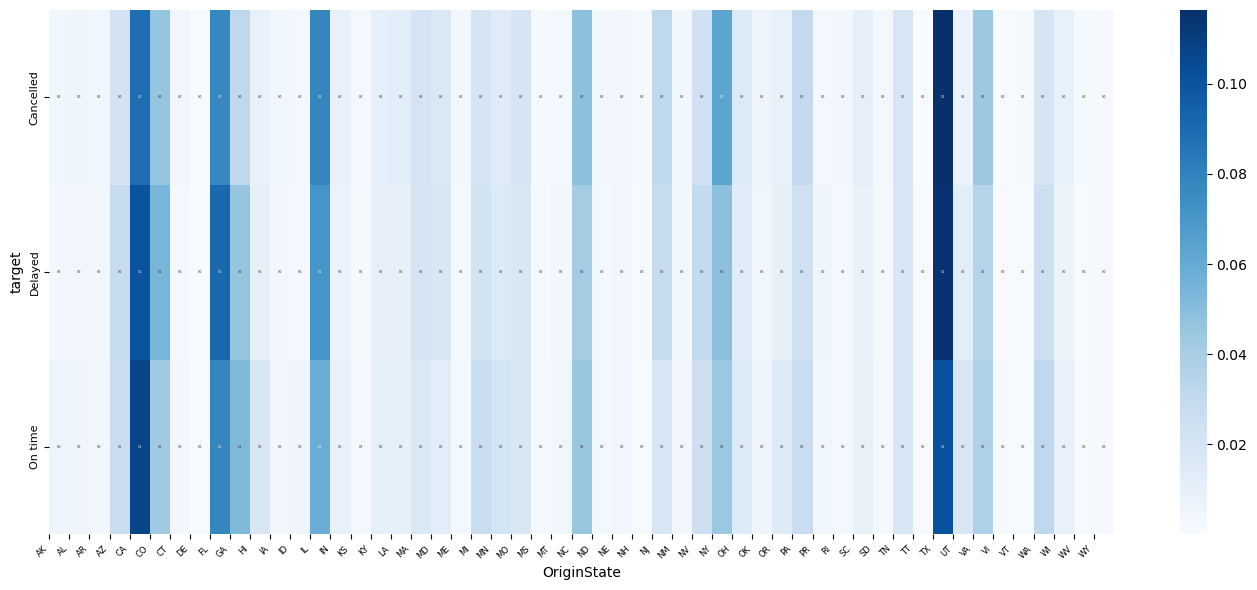

In [35]:
plt.figure(figsize=(14, 6))

ct_norm = pd.crosstab(
    df["target"],
    df["OriginState"],
    normalize="index"
)

ax = sns.heatmap(
    ct_norm,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    annot_kws={"size": 2}
)

ax.set_xticks(range(len(ct_norm.columns)))
ax.set_xticklabels(
    ct_norm.columns,
    rotation=45,
    ha="right",
    fontsize=6
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontsize=8
)

plt.tight_layout()
plt.show()

Most of the flights are coming from CA & TX - so it makes sense why it shows so many in all 4 categories. Highest Cancelled are in CA, CO, L, NC, NY, & TX.

Now that we looked at origin state, lets look at DestState

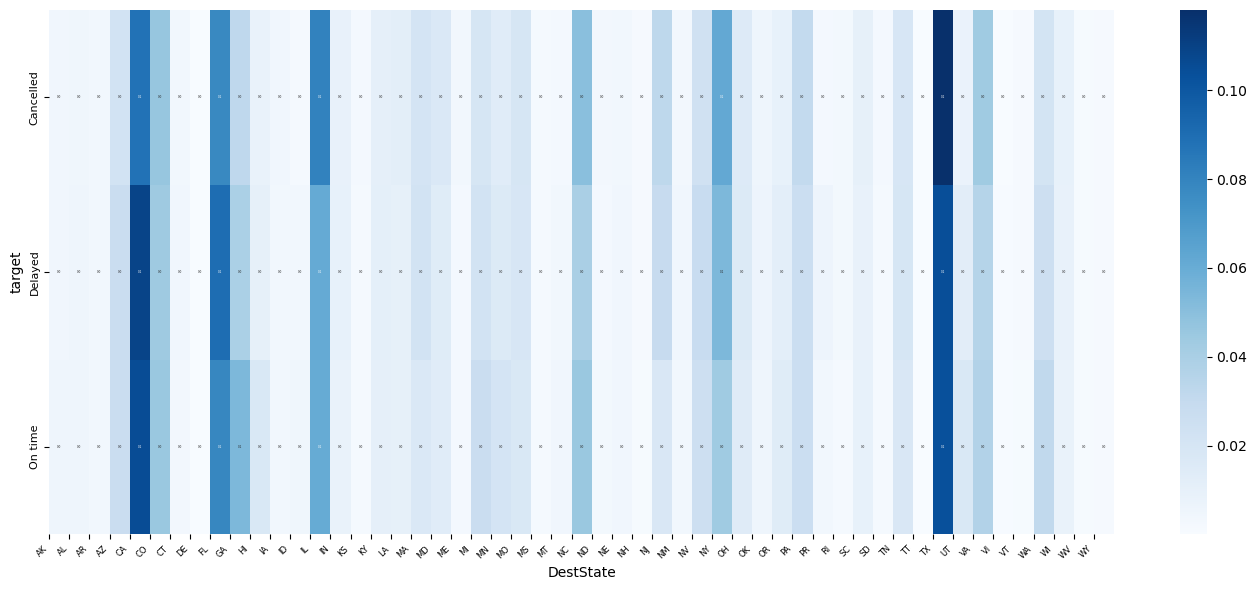

In [36]:
plt.figure(figsize=(14, 6))

ct_norm = pd.crosstab(
    df["target"],
    df["DestState"],
    normalize="index"
)

ax = sns.heatmap(
    ct_norm,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    annot_kws={"size": 2}
)

ax.set_xticks(range(len(ct_norm.columns)))
ax.set_xticklabels(
    ct_norm.columns,
    rotation=45,
    ha="right",
    fontsize=6
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontsize=8
)

plt.tight_layout()
plt.show()

Similar patterns there! A higher density of the flights fly from CA, TX. 

## Departure Time
Let's see if the time block in which the flight was schedules to leave has a correlation too!


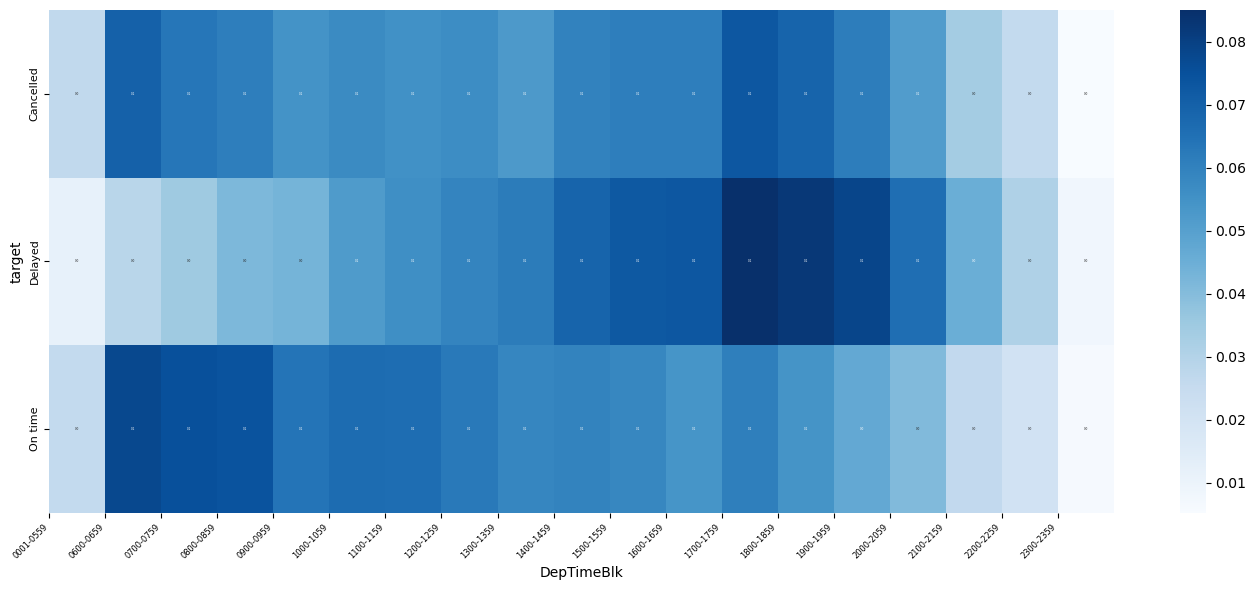

In [37]:
plt.figure(figsize=(14, 6))

ct_norm = pd.crosstab(
    df["target"],
    df["DepTimeBlk"],
    normalize="index"
)

ax = sns.heatmap(
    ct_norm,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    annot_kws={"size": 2}
)

ax.set_xticks(range(len(ct_norm.columns)))
ax.set_xticklabels(
    ct_norm.columns,
    rotation=45,
    ha="right",
    fontsize=6
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontsize=8
)

plt.tight_layout()
plt.show()

From this heatmap - 
- we can see that on time flights are highest in the early morning from 6-9am
- on time flights gradually decrease throughout the day
- Delays peak in the mid to late afternoon (2-9pm)

Let's look at distance again, but this time the groups so we can bin the values. - Distance Intervals, every 250 Miles, for Flight Segment


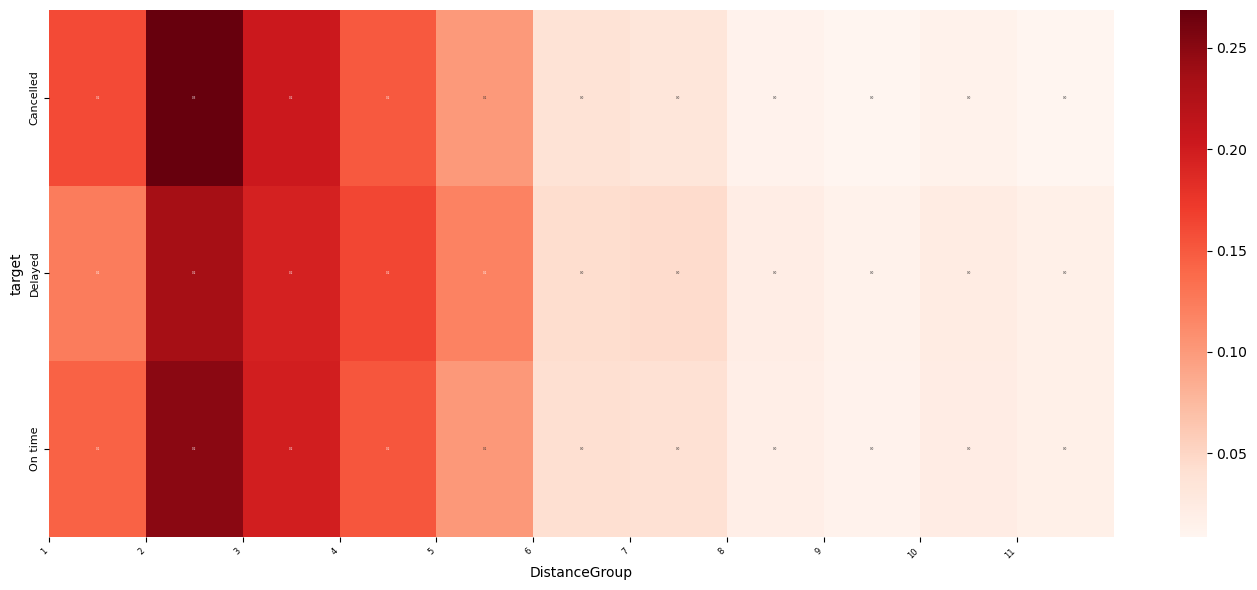

In [38]:
plt.figure(figsize=(14, 6))

ct_norm = pd.crosstab(
    df["target"],
    df["DistanceGroup"],
    normalize="index"
)

ax = sns.heatmap(
    ct_norm,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    annot_kws={"size": 2}
)

ax.set_xticks(range(len(ct_norm.columns)))
ax.set_xticklabels(
    ct_norm.columns,
    rotation=45,
    ha="right",
    fontsize=6
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontsize=8
)

plt.tight_layout()
plt.show()

From the heatmap above, there are a lot of flights in the range 2-3, 250-500 miles. This only tells us the density of the flights.

## Temporal
Now let us see a calendar to see times of the year

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


<Figure size 1600x600 with 0 Axes>

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


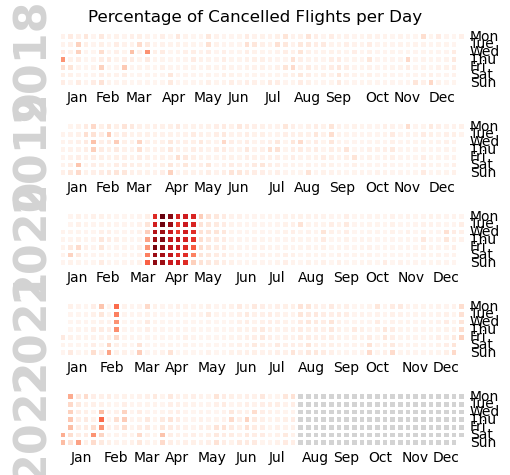

In [39]:
# make sure FlightDate is datetime
df["FlightDate"] = pd.to_datetime(df["FlightDate"])

# flag cancelled flights
df["is_cancelled"] = (df["target"] == "Cancelled").astype(int)

# group by date
daily = df.groupby("FlightDate")["is_cancelled"].agg(["sum", "count"])
daily["pct_cancelled"] = daily["sum"] / daily["count"]


# need a Series with a datetime index
pct_series = daily["pct_cancelled"]
pct_series.index.name = "date"
plt.rcParams.update({"font.family": "DejaVu Sans"})

plt.figure(figsize=(16, 6))
calmap.calendarplot(pct_series, cmap="Reds", fillcolor="lightgrey")

plt.suptitle("Percentage of Cancelled Flights per Day")
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


<Figure size 1600x600 with 0 Axes>

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


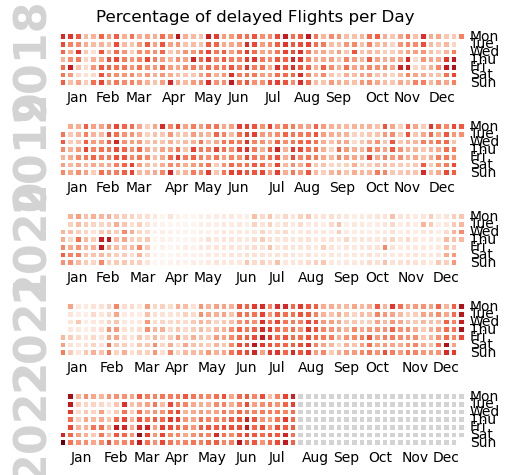

In [40]:
# make sure FlightDate is datetime
df["FlightDate"] = pd.to_datetime(df["FlightDate"])

# flag delayed flights
df["is_delayed"] = (df["target"] == "Delayed").astype(int)

# group by date
daily = df.groupby("FlightDate")["is_delayed"].agg(["sum", "count"])
daily["pct_delayed"] = daily["sum"] / daily["count"]


# need a Series with a datetime index
pct_series = daily["pct_delayed"]
pct_series.index.name = "date"

plt.figure(figsize=(16, 6))
calmap.calendarplot(pct_series, cmap="Reds", fillcolor="lightgrey")

plt.suptitle("Percentage of delayed Flights per Day")
plt.show()

For the year of 2020 - there were lots of cancellelations during the start of the pandemic.
We can consider dropping the year 2020 since this will cause a lot of noise in the training dataset.

## Common Flight Paths/Top Routes

In [41]:
df[df.target == 'Delayed'].OriginCityName.value_counts().sort_values(ascending=False)[0:10]

OriginCityName
Chicago, IL              335983
Denver, CO               242932
Dallas/Fort Worth, TX    212084
Atlanta, GA              208826
New York, NY             178601
Houston, TX              167293
Charlotte, NC            140263
Los Angeles, CA          139934
Newark, NJ               133613
Washington, DC           132377
Name: count, dtype: int64

In [42]:
# Are there certain routes/planes that are more likely to get delayed? Not in particular.
df[df.target == 'Delayed'].Flight_Number_Marketing_Airline.value_counts().sort_values(ascending=False)[0:10]

Flight_Number_Marketing_Airline
706    2324
665    2152
679    2140
403    2095
711    2074
678    2067
61     2037
352    2032
566    2018
801    2017
Name: count, dtype: int64

In [43]:
# Are there certain routes/planes that are more likely to get cancelled? - Not in particular.
df[df.target == 'Cancelled'].Flight_Number_Marketing_Airline.value_counts().sort_values(ascending=False)[0:10]

Flight_Number_Marketing_Airline
16      346
657     327
676     323
1202    309
347     300
2134    299
679     294
678     293
2101    292
2001    286
Name: count, dtype: int64

In [44]:
# create a route column for convenience
df['route'] = df['Origin'] + " → " + df['Dest']

# total flights per route
route_counts = df.groupby('route').size().rename('total_flights')

# number of cancelled flights per route
route_cancelled = df[df['target'] == 'Cancelled'].groupby('route').size().rename('cancelled_flights')

# number of delayed flights per route
route_delayed = df[df['target'] == 'Delayed'].groupby('route').size().rename('delayed_flights')

# combine into a single DataFrame
route_summary = pd.concat([route_counts, route_cancelled, route_delayed], axis=1).fillna(0)

# calculate percentages
route_summary['pct_cancelled'] = route_summary['cancelled_flights'] / route_summary['total_flights']
route_summary['pct_delayed'] = route_summary['delayed_flights'] / route_summary['total_flights']

# sort by highest cancellation rate
route_summary_sorted = route_summary.sort_values(by='pct_cancelled', ascending=False)

route_summary_sorted.head(10)

,total_flights,cancelled_flights,delayed_flights,pct_cancelled,pct_delayed
route,,,,,
TUS → AZA,3,3.0,0.0,1.0,0.0
GFK → BIS,1,1.0,0.0,1.0,0.0
AUS → ACY,1,1.0,0.0,1.0,0.0
ATW → CMH,1,1.0,0.0,1.0,0.0
TTN → SFB,1,1.0,0.0,1.0,0.0
CVG → MEM,3,3.0,0.0,1.0,0.0
FWA → BNA,1,1.0,0.0,1.0,0.0
GEG → LWS,1,1.0,0.0,1.0,0.0
OKC → SJC,1,1.0,0.0,1.0,0.0


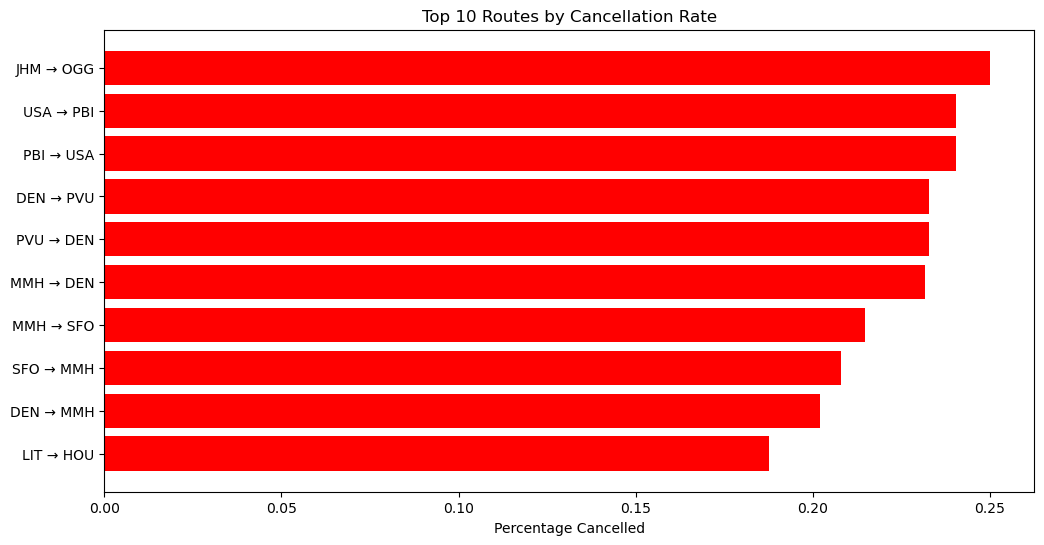

In [45]:
min_flights = 50  # only consider routes with at least 50 flights
route_summary_filtered = route_summary[route_summary['total_flights'] >= min_flights]
route_summary_filtered.sort_values(by='pct_cancelled', ascending=False).head(10)

top_routes = route_summary_filtered.sort_values('pct_cancelled', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.barh(top_routes.index, top_routes['pct_cancelled'], color='red')
plt.xlabel("Percentage Cancelled")
plt.title("Top 10 Routes by Cancellation Rate")
plt.gca().invert_yaxis()  # largest on top
plt.show()

USA has been verified as an airport in Concord, NC. Below we fix the duplicate naming.

In [46]:
df[df.Origin == 'USA'].shape

(5294, 69)

In [47]:
df[df.Dest == 'USA'].shape

(5287, 69)

In [48]:
df[df.Origin == 'USA'].OriginAirportID.unique()

array([12544])

In [49]:
df[df.Dest == 'USA'].DestCityName.unique()

array(['Concord, NC', 'CONCORD, NC'], dtype=object)

In [50]:
df[df.Origin == 'USA'].OriginCityName.unique()

array(['Concord, NC', 'CONCORD, NC'], dtype=object)

In [51]:
# Fixing the naming convention of Origin/Dest City name
df["OriginCityName"] = (
    df["OriginCityName"]
      .str.split(", ")
      .apply(lambda x: f"{x[0].title()}, {x[1].upper()}" if len(x) == 2 else x[0].title())
)
df["DestCityName"] = (
    df["DestCityName"]
      .str.split(", ")
      .apply(lambda x: f"{x[0].title()}, {x[1].upper()}" if len(x) == 2 else x[0].title())
)

In [52]:
df[df.Origin == 'USA'].OriginCityName.unique()

array(['Concord, NC'], dtype=object)

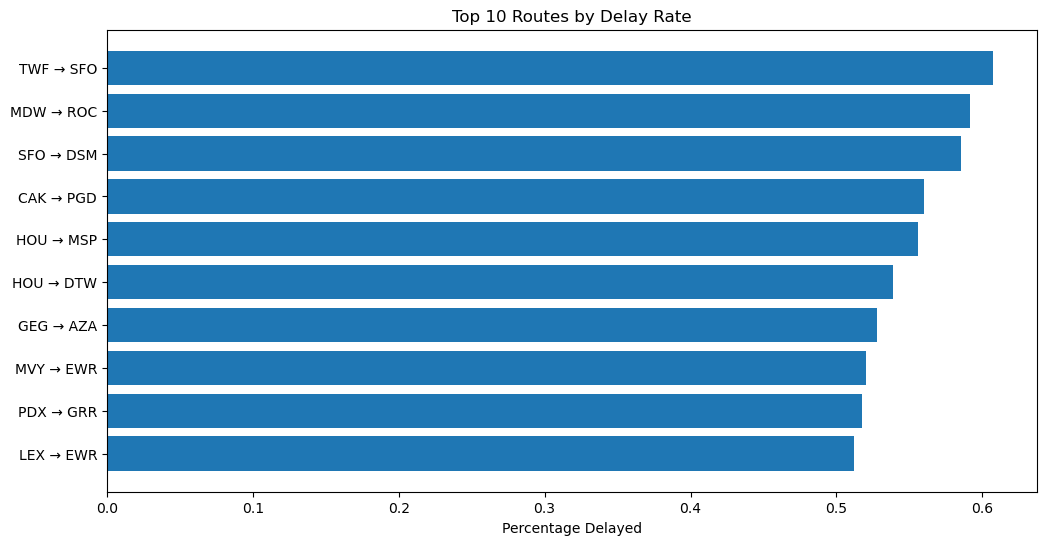

In [53]:
# create route column if not already created
df["route"] = df["Origin"] + " → " + df["Dest"]

# total flights per route
route_counts = df.groupby("route").size().rename("total_flights")

# delayed flights per route
route_delayed = (
    df[df["target"] == "Delayed"]
    .groupby("route")
    .size()
    .rename("delayed_flights")
)

# combine
route_summary = pd.concat([route_counts, route_delayed], axis=1).fillna(0)

# calculate delay percentage
route_summary["pct_delayed"] = (
    route_summary["delayed_flights"] / route_summary["total_flights"]
)

min_flights = 50
route_summary = route_summary[route_summary["total_flights"] >= min_flights]

# sort
top_delayed_routes = route_summary.sort_values(
    "pct_delayed", ascending=False
)

top10 = top_delayed_routes.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top10.index, top10["pct_delayed"])
plt.xlabel("Percentage Delayed")
plt.title("Top 10 Routes by Delay Rate")
plt.gca().invert_yaxis()
plt.show()

## Delayed Flights Analysis

In [54]:
### delay distribution (delayed flights only)
delayed = df[df['target'] == 'Delayed']['DepDelay'].dropna()
delayed.describe()

count    4.904094e+06
mean     6.864991e+01
std      9.219186e+01
min      1.500000e+01
25%      2.400000e+01
50%      4.100000e+01
75%      7.900000e+01
max      7.223000e+03
Name: DepDelay, dtype: float64

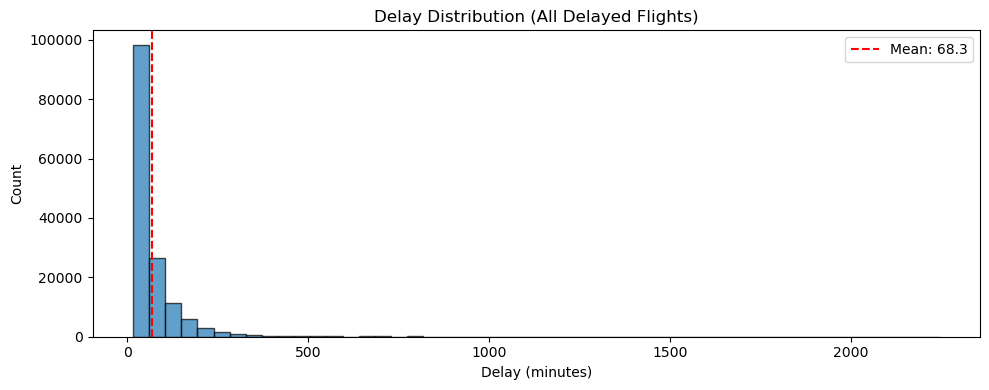

In [55]:
# delayed sample
delayed_sample = delayed.sample(min(150000, len(delayed)), random_state=42)

# histogram for delayed flights
plt.figure(figsize=(10,4))  
plt.hist(delayed_sample, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(delayed_sample.mean(), linestyle='--', label=f"Mean: {delayed_sample.mean():.1f}", color='red')
plt.title('Delay Distribution (All Delayed Flights)')
plt.xlabel('Delay (minutes)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

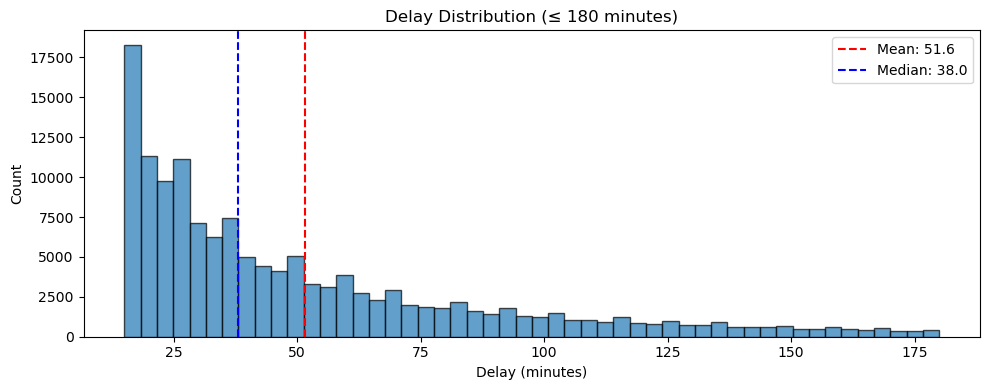

In [56]:
# trimmed hist
delayed_trim = delayed_sample[delayed_sample <= 180]
plt.figure(figsize=(10,4))
plt.hist(delayed_trim, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(delayed_trim.mean(), linestyle='--', label=f"Mean: {delayed_trim.mean():.1f}", color='red')
plt.axvline(delayed_trim.median(), linestyle='--', label=f"Median: {delayed_trim.median():.1f}", color='blue')
plt.title('Delay Distribution (≤ 180 minutes)')
plt.xlabel('Delay (minutes)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

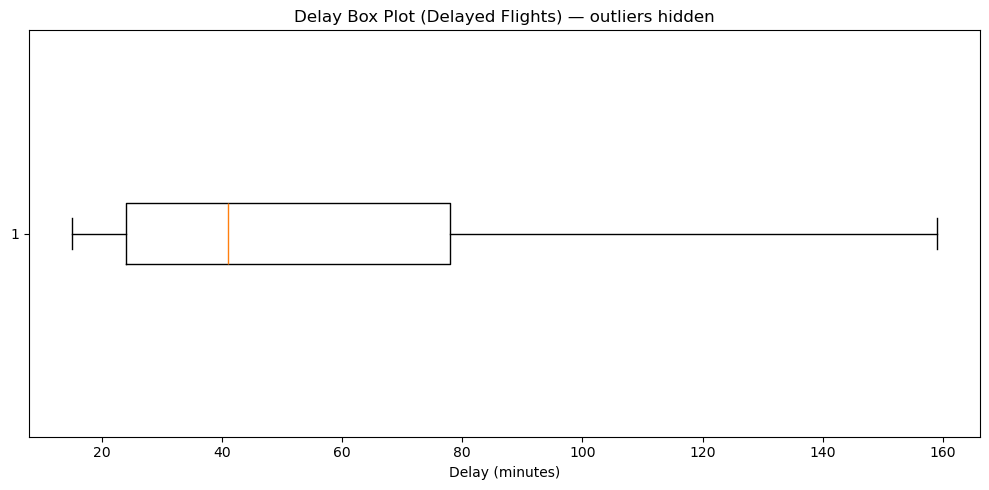


Median: 41.00 minutes
IQR: 54.00 minutes


In [57]:
# boxplot for delayed flights
plt.figure(figsize=(10,5))
plt.boxplot(delayed_sample, vert=False, showfliers=False)
plt.title('Delay Box Plot (Delayed Flights) — outliers hidden')
plt.xlabel('Delay (minutes)')
plt.tight_layout()
plt.show()

median = delayed_sample.median()
iqr = delayed_sample.quantile(0.75) - delayed_sample.quantile(0.25)
print(f'\nMedian: {median:.2f} minutes')
print(f'IQR: {iqr:.2f} minutes')

### Delay Distribution plots 
1. delayed dist hitogram (all flights)
2. delayed dist hist (trimmed)
3. delayed flights boxplot

The distribution for delayed flights is heavily right-skewed with a long tail extending beyond 3 hrs. The median time delay for flights is 41 min with a mean of 69 min. Most delays cluster between 15-60 min. 

- in the trimmed histogram you can see the distribution more clearly 
median < mean. 
- The boxplot shows a lot of extreme outliers (long tail)

- the large difference between mean and median shows that there is a wide range of values representing a "delayed" flight, and one flight being delayed 3 hrs can have drastically different reasons than one flight being delayed 20 min. 

**regression task to capture the difference is delay durations**

In [58]:
# delete vars for memory
del delayed, delayed_sample, delayed_trim
gc.collect()

17979

In [59]:
# Correlation between flight status and delay duration
sample = df.sample(200000, random_state=42)
sample['target_num'] = sample['target'].map({'On time': 0, 'Delayed': 1, 'Cancelled': 2})
status_delay_corr = sample[['DepDelay', 'target_num']].corr().iloc[0, 1]
print(f'\nCorrelation between Departure Delay and Target: {status_delay_corr:.2f}')

del sample
gc.collect()


Correlation between Departure Delay and Target: 0.57


0

In [60]:
# daily delayed flights stats
daily_stats = df.groupby('FlightDate').agg({
'DepDelay': 'mean',
'target': lambda x: (x == 'Delayed').mean()
}).reset_index()
daily_stats.columns = ['date', 'avg_delay', 'delay_rate']

print(f'\nNumber of unique days with flight data: {len(daily_stats)}')


Number of unique days with flight data: 1673


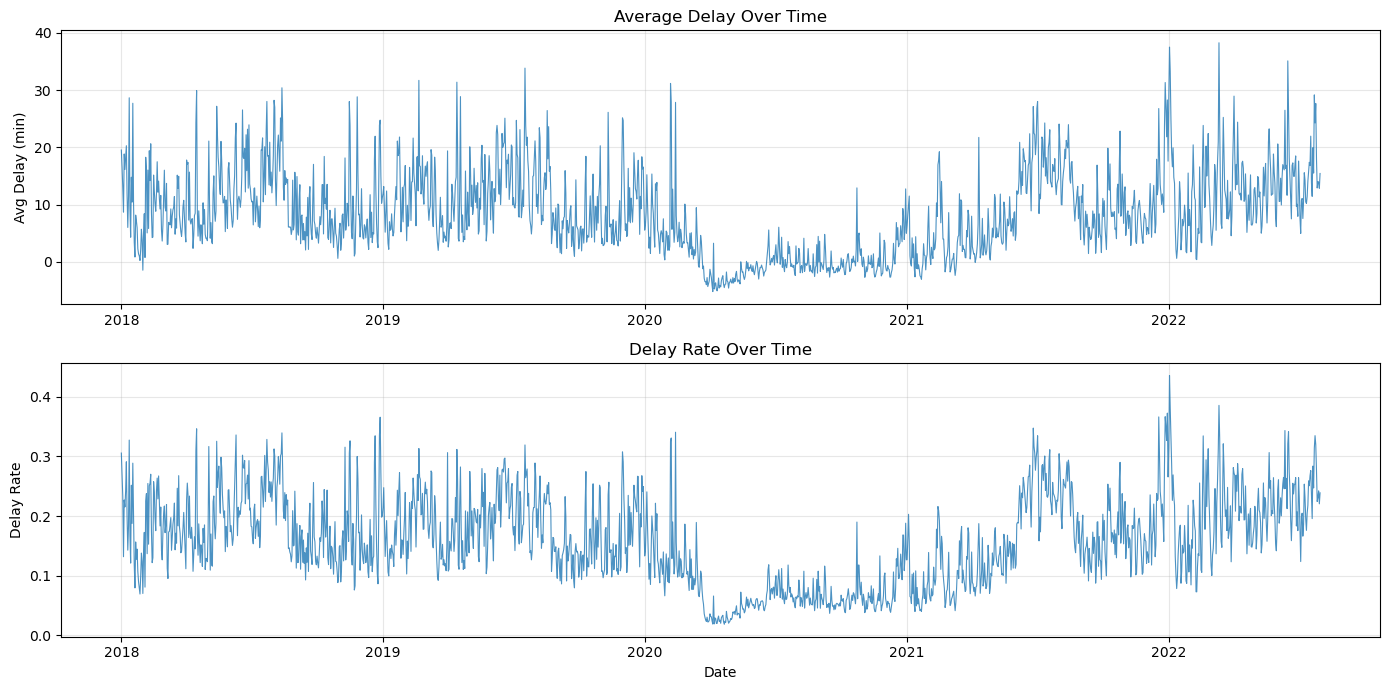

In [61]:
# avg delay and delay rate over time
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(daily_stats['date'], daily_stats['avg_delay'], linewidth=0.8, alpha=0.8)
axes[0].set_title('Average Delay Over Time')
axes[0].set_ylabel('Avg Delay (min)')
axes[0].grid(alpha=0.3)


axes[1].plot(daily_stats['date'], daily_stats['delay_rate'], linewidth=0.8, alpha=0.8)
axes[1].set_title('Delay Rate Over Time')
axes[1].set_ylabel('Delay Rate')
axes[1].set_xlabel('Date')
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

### **Time series for delay rate**

- shows us temporal variation across 2018-2019 with notable flunctuations from almost 0 - 30+ mmin average delays. 

- major dip in 2020 --> **covid/lockdown**

* Shows us that delays vary over time due to different factors like, seasonal effects, weather patterns, and opterational factors.

- looking at these plots they seem very similar, which shows us that days with a higher proportion of delayed flights also tend to experience longer average delays.

----> Disruptions affect both how often and how severely flights are delayed. 

### To look for patterns within time series: ACF & PCAF

### **Autocorrelation Function (ACF) + Partial ACF (PCAF)**

**results = signifcant when above shadow blue box**

**ACF**: strong positive autocorrelation at day 1 --> yesterday's delays predict today's then leads to a gradual decrease through day 7.
 
 * tells us that past delays contain predictive info about future delays

**PCAF**: strong partial autocorrelation as day 1, with smaller but still important correlations at days 2-7. 

- since data shows significant results for days 1-7 it can mean that a week of delays can influence current conditions. 



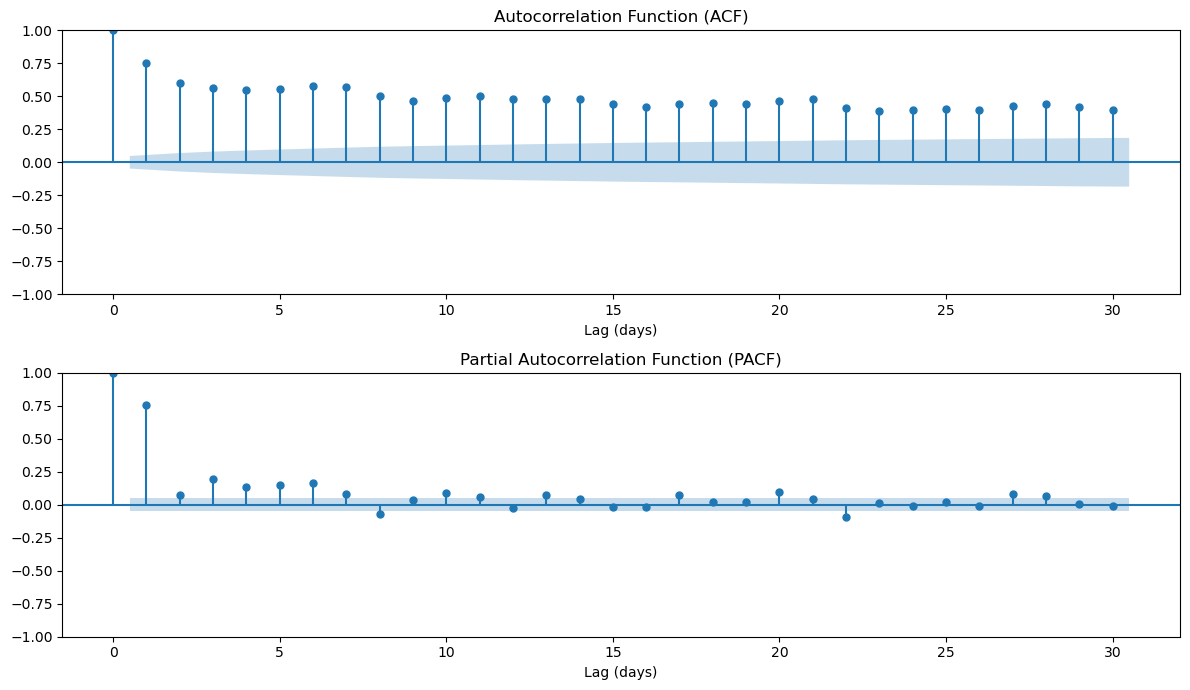

In [62]:
daily_delay = daily_stats.set_index('date')['avg_delay'].dropna()


fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(daily_delay, lags=30, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lag (days)')


plot_pacf(daily_delay, lags=30, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].set_xlabel('Lag (days)')


plt.tight_layout()
plt.show()

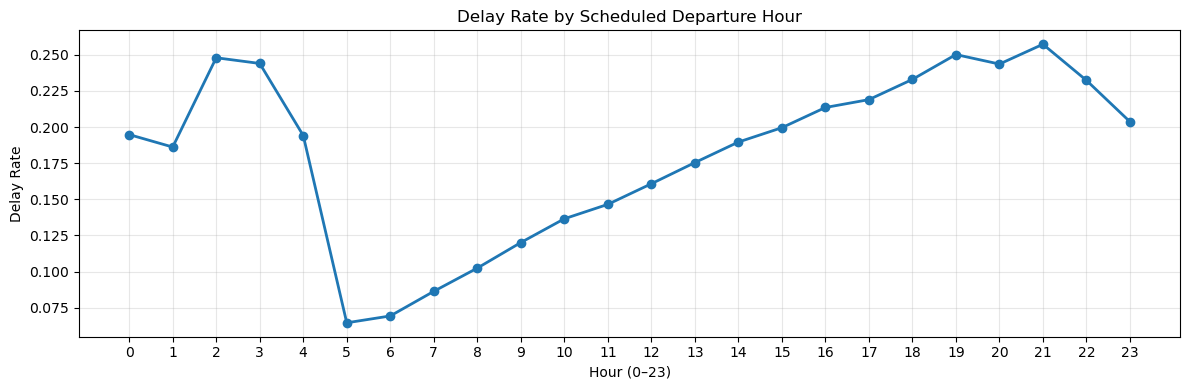

In [63]:
# hour of day pattern
df['dep_hour'] = df['CRSDepTime'] // 100


hourly_delays = df.groupby('dep_hour')['target'].apply(lambda x: (x == 'Delayed').mean()).reset_index()
hourly_delays.columns = ['hour', 'delay_rate']


plt.figure(figsize=(12, 4))
plt.plot(hourly_delays['hour'], hourly_delays['delay_rate'], marker='o', linewidth=2)
plt.title('Delay Rate by Scheduled Departure Hour')
plt.xlabel('Hour (0–23)')
plt.ylabel('Delay Rate')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Delay Rate --- Schedules dep hr
- early mornings (5-7am) have the lowest delay rates
- delay rates increase steadily as day progresses
- evening and late night flights (18-22) experience the highest delay rates

**later flights more likely to delayed due to accumulated delays from earlier delays**

## Weather Coverage

In [64]:
# merging flights and weather
weather = pd.read_parquet('../../data/raw/flightsweather.parquet')
weather['valid'] = pd.to_datetime(weather['valid'])
weather['date'] = weather['valid'].dt.date
weather['hour'] = weather['valid'].dt.hour


weather_hourly = weather.groupby(['airport_code', 'date', 'hour']).agg({
'tmpf': 'mean',
'vsby': 'mean',
'sknt': 'mean',
'p01i': 'sum',
'relh': 'mean',
'gust': 'max'
}).reset_index()


del weather
gc.collect()

df['date'] = df['FlightDate'].dt.date

flights_merged = df.merge(
weather_hourly,
left_on=['Origin', 'date', 'dep_hour'],
right_on=['airport_code', 'date', 'hour'],
how='left'
).drop(['airport_code', 'hour'], axis=1, errors='ignore') 

weather_coverage = (~flights_merged['tmpf'].isna()).mean() * 100
print(f"Weather data coverage: {weather_coverage:.2f}% of flights")


del weather_hourly
gc.collect()


Weather data coverage: 60.25% of flights


0


Correlation between weather features and Departure Delay:
vsby   -0.038599
relh   -0.006727
tmpf    0.040436
gust    0.042103
p01i    0.042705
sknt    0.058508
Name: DepDelay, dtype: float64


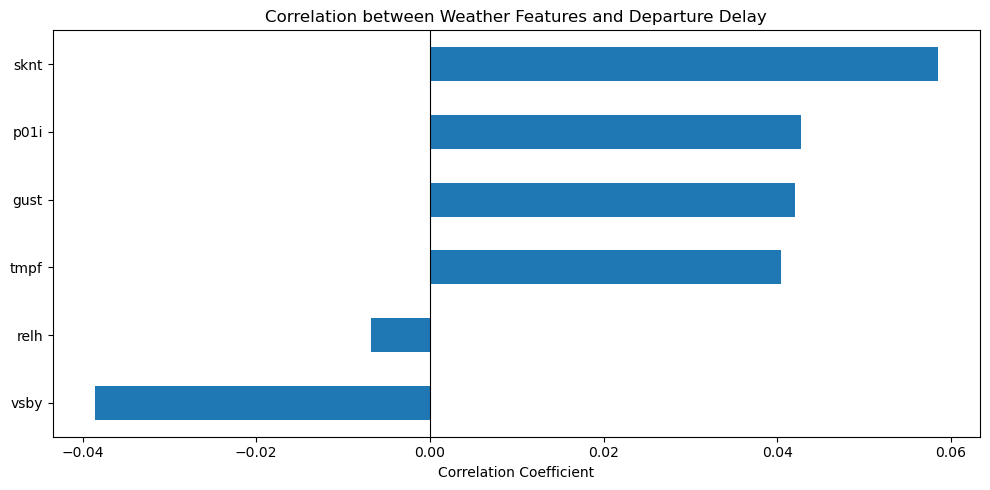

3298

In [65]:
flights_with_weather = flights_merged.dropna(subset=['tmpf']).copy()
weather_cols = ['tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust']


weather_sample = flights_with_weather.sample(min(200000, len(flights_with_weather)), random_state=42)


weather_corrs = weather_sample[weather_cols + ['DepDelay']].corr()['DepDelay'].drop('DepDelay').sort_values()
print("\nCorrelation between weather features and Departure Delay:")
print(weather_corrs)


plt.figure(figsize=(10, 5))
weather_corrs.plot(kind='barh')
plt.title('Correlation between Weather Features and Departure Delay')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


del weather_sample, flights_with_weather
gc.collect()

### Weather Features Correlations
* meaningful correlation with departure deplays: 

**Positive correlations (associated with longer delays):**
1. sknt (wind speed)
2. gusts (sudden spikes in wind speed)
3. p01i (precipitation)
4. tmpf (temperature)

**Negative Correlations (shorter delays):**
1. vsby (visibility) ---> better visibility reduces delays
2. relh (relative humidity--> fog, clouds)

**Weather conditions are proving to possible being good predictive features**


## **Airports & Airlines**

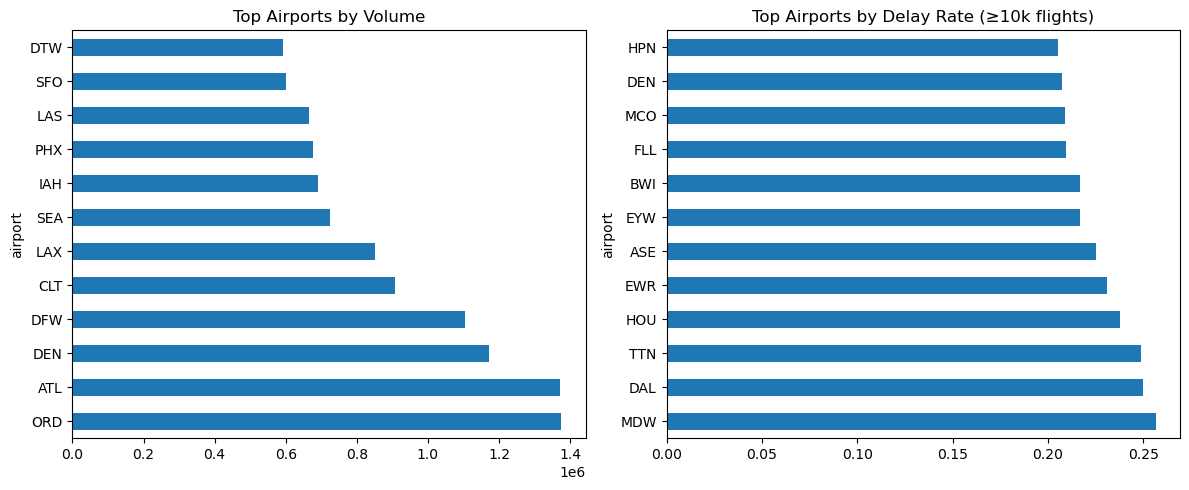

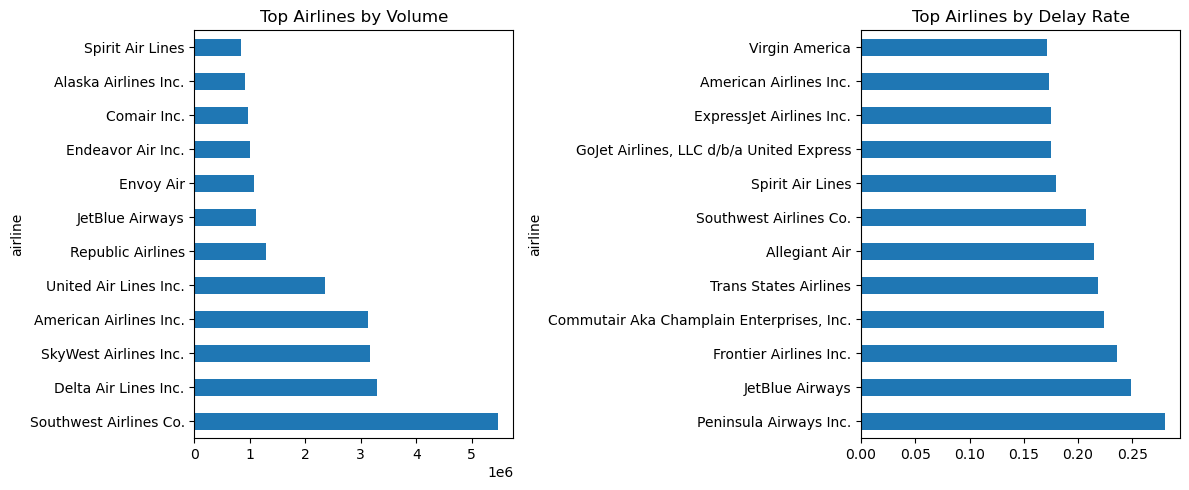

In [66]:
# airport and airline comparisons
airport_stats = df.groupby('Origin').agg(
flights=('target', 'size'),
delay_rate=('target', lambda x: (x == 'Delayed').mean())
).reset_index().rename(columns={'Origin': 'airport'})


high_volume = airport_stats[airport_stats['flights'] >= 10000]


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
airport_stats.nlargest(12, 'flights').plot(x='airport', y='flights', kind='barh', ax=axes[0], legend=False)
axes[0].set_title('Top Airports by Volume')


high_volume.nlargest(12, 'delay_rate').plot(x='airport', y='delay_rate', kind='barh', ax=axes[1], legend=False)
axes[1].set_title('Top Airports by Delay Rate (≥10k flights)')


plt.tight_layout()
plt.show()


airline_stats = df.groupby('Airline').agg(
flights=('target', 'size'),
delay_rate=('target', lambda x: (x == 'Delayed').mean())
).reset_index().rename(columns={'Airline': 'airline'})


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
airline_stats.nlargest(12, 'flights').plot(x='airline', y='flights', kind='barh', ax=axes[0], legend=False)
axes[0].set_title('Top Airlines by Volume')


airline_stats.nlargest(12, 'delay_rate').plot(x='airline', y='delay_rate', kind='barh', ax=axes[1], legend=False)
axes[1].set_title('Top Airlines by Delay Rate')


plt.tight_layout()
plt.show()

### Airports
* airports ORD, ATL, DEN have more flights yet they are not seen to have a lot of delays. 

* Smaller airports (with less flights) show higher delay rates

### Airlines
* Southwest has the most flights but maintains moderate delay rates. Smaller airlines (peninsula, jetblue) show the highest delay rates, even though they are not in the top airlines by volume. 

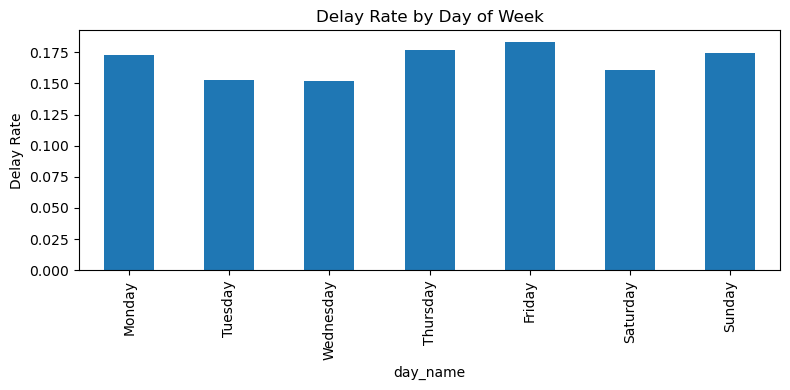

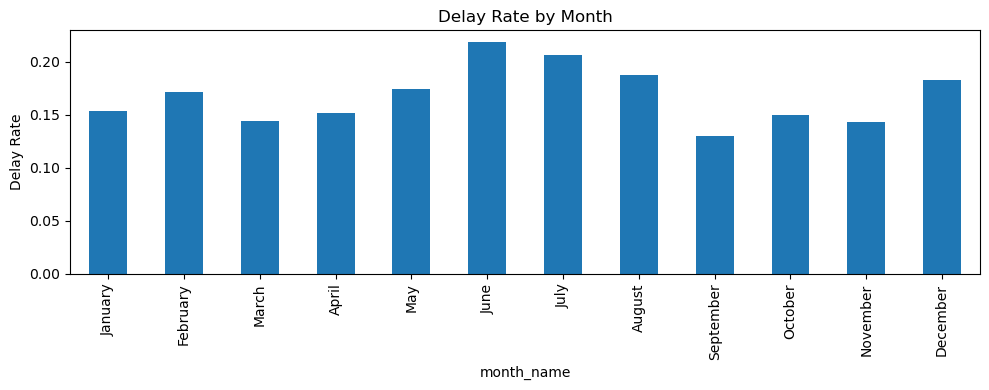

In [67]:
# day of week + month patterns
df['day_name'] = df['FlightDate'].dt.day_name()
dow_delays = df.groupby('day_name')['target'].apply(lambda x: (x == 'Delayed').mean()).reindex(
['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
plt.figure(figsize=(8, 4))
dow_delays.plot(kind='bar')
plt.title('Delay Rate by Day of Week')
plt.ylabel('Delay Rate')
plt.tight_layout()
plt.show()


df['month_name'] = df['FlightDate'].dt.month_name()
month_delays = df.groupby('month_name')['target'].apply(lambda x: (x == 'Delayed').mean()).reindex(
['January','February','March','April','May','June','July','August','September','October','November','December']
)
plt.figure(figsize=(10, 4))
month_delays.plot(kind='bar')
plt.title('Delay Rate by Month')
plt.ylabel('Delay Rate')
plt.tight_layout()
plt.show()

### Delay by week & month
#### **Day of Week:**
- Friday = highest delay rate, then thursday and monday. mid-week (tuesday-wednesday)  show lower rates

#### **Monthly Patterns:**
- Summer months (June-July) ---> highest delay rates 
- September = lowest rates
- winter months = moderate rates 

**seasonal patterns for model to capture**

### **Pre-Covid Difference in Flights**

* daily average delayes and delay rates show 

In [68]:
# see the difference in weather impact pre/post COVID
# 2018-2019 
df = df[df['Year'] < 2020].copy()

In [69]:
df.shape

(13781196, 73)


Top features correlated with delay (flight + weather combined):
dep_hour     0.087497
sknt         0.062503
gust         0.053497
p01i         0.050286
tmpf         0.035421
DayOfWeek    0.011900
Distance     0.010770
relh         0.000163
Month       -0.005979
vsby        -0.043038
Name: DepDelay, dtype: float64


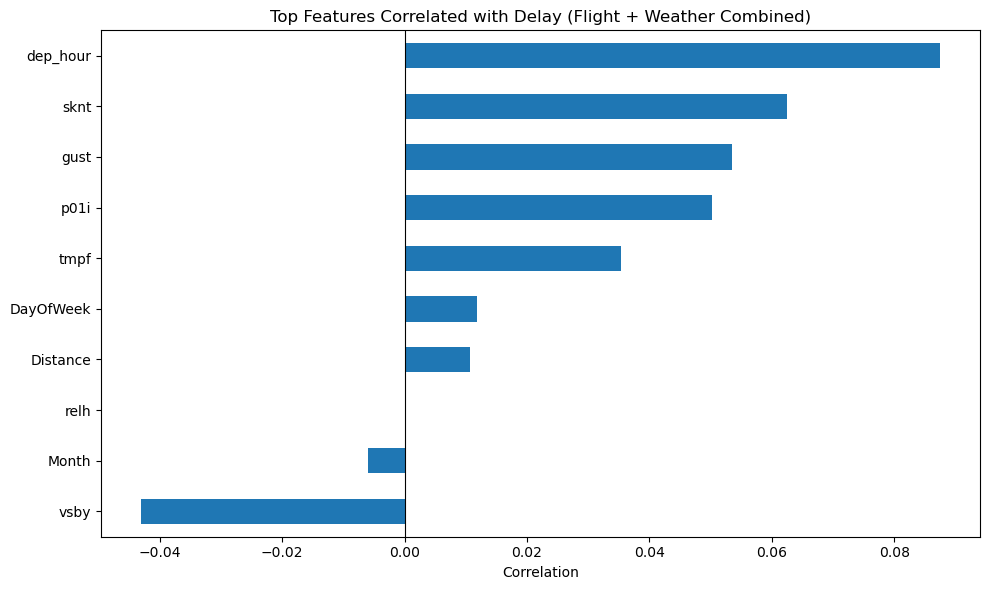

21408

In [70]:
# Combined feature importance (flight + weather together)
print("\nTop features correlated with delay (flight + weather combined):")
sample_merged = flights_merged.sample(min(150000, len(flights_merged)), random_state=42)

feature_cols = ['Distance', 'Month', 'DayOfWeek', 'dep_hour', 
                'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust']
feature_cols = [c for c in feature_cols if c in sample_merged.columns and 
                sample_merged[c].notna().sum() > 1000]

all_corrs = sample_merged[feature_cols + ['DepDelay']].corr()['DepDelay'].drop('DepDelay')
print(all_corrs.sort_values(ascending=False).head(10))

plt.figure(figsize=(10, 6))
all_corrs.sort_values().tail(12).plot(kind='barh')
plt.title('Top Features Correlated with Delay (Flight + Weather Combined)')
plt.xlabel('Correlation')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

del sample_merged
gc.collect()

### **Features Correlated with Delay ---> Flight + Weather (2018-2019)**

* done to avoid the dip/distortion seen in 2020 

* better for explaining delay behavior 

**Strongest Positive Correlations:**
- **dep_hours**
- **sknt**
- **gust**
- **p01i**
- **tmpf**

**Neg corr:**
- **vsby**
- **relh**

**Tells us that the best results will come from combining both flight and weather factors/conditions**